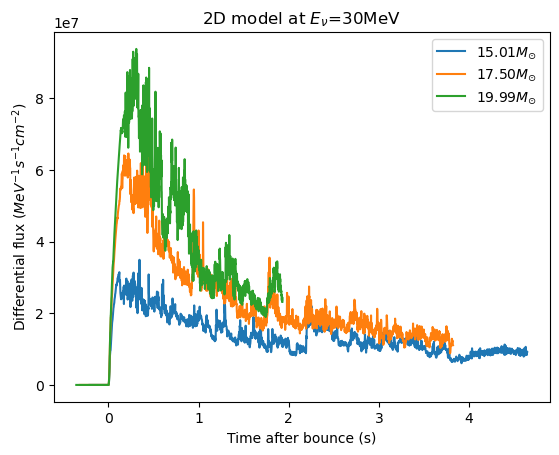

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline, RectBivariateSpline
import definition
# from setup import index

effective_data_file = ['15.01', '15.05', '16.43', '16.65', '16.99', '17.00', '17.07', '17.10', '17.40', 
                       '17.48', '17.50', '17.51', '17.83', '18.04', '18.05', '18.09', '18.10', '18.50',
                       '19.02', '19.56', '19.83', '19.99'] 

file_str = effective_data_file[0] # index from 0 to 21, corresponding to the 22 data files

D = definition.Distance_SN1987 # Distance to SN 1987A in cm

def filename(file_str):
    return "F:/Neutrino_SI/Bin/2D_trim_data/"+ file_str +"/nuspec.1.xg"   

def read_xg(file):

    data = []
    current_time = None

    with open(file) as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            # time line
            if line.startswith("#"):
                current_time = float(line.split()[-1])
                continue

            # data line
            E, EdFdE = map(float, line.split())

            data.append({
                "time": current_time,
                "E": E,
                "EdFdE": EdFdE
            })

    df = pd.DataFrame(data)

    return df


def flux_emulator(t, E, file_str, grid=False):
    """
    Evaluates the pre-computed 2D spline.
    """
    df = read_xg(filename(file_str))
    E_space_2d = np.linspace(4, 75, 1000)
    times_space = np.array(df["time"].unique()) # 4139 times
    energies_space = np.array(df["E"]).reshape(len(times_space), 12) # 49668   
    Eflux = np.array(df["EdFdE"]).reshape(len(times_space), 12)

    flux = Eflux * 1e75 * 624150.9074461 / energies_space / (4 * np.pi * D**2)

    grid_F = np.array([make_interp_spline(energies_space[i, :], flux[i, :], k=3)(E_space_2d) for i in range(len(times_space))])

    fast_flux_interpolator = RectBivariateSpline(times_space, E_space_2d, grid_F, kx=3, ky=3)

    return np.clip(fast_flux_interpolator(t, E, grid=grid), 0, None) # Ensure non-negative flux

def time_limit(file_str):
    df = read_xg(filename(file_str))
    return df["time"].min(), df["time"].max()

E_vals = np.linspace(4, 60, 1000)
# plt.figure(figsize=(10, 6))
file_str_test = ['15.01', '17.50', '19.99']
E_test  = 30
for i in range(len(file_str_test)):
    t_vals = np.linspace(time_limit(file_str_test[i])[0], time_limit(file_str_test[i])[1], 2000)
    plt.plot(t_vals, flux_emulator(t_vals, E_test, file_str_test[i]), label = str(file_str_test[i]) + r"$M_{\odot}$")


plt.xlabel("Time after bounce (s)")
plt.ylabel(r"Differential flux ($MeV^{-1}s^{-1}cm^{-2}$)")
plt.title(r"2D model at $E_\nu$="+str(E_test) +  "MeV" ) 
plt.legend()
plt.show()

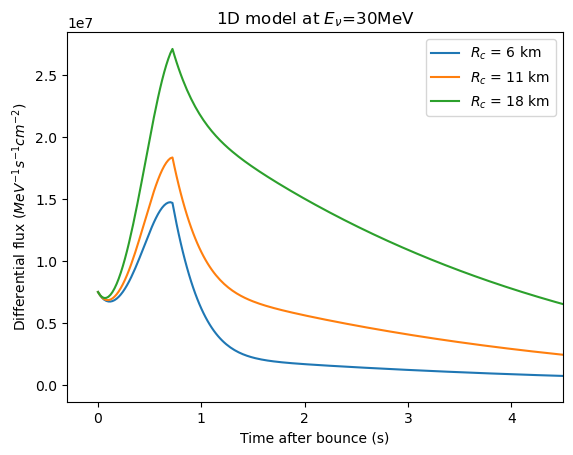

In [24]:
from SignalRate_1d import Flux_total

E_1d = 30
t_1d = np.linspace(0, 20, 1000)
parameters_1d_1 = [6, 5.35, 4.79, 0.39, 2.07, 0.72, 0, -8]
parameters_1d_2 = [11, 5.35, 4.79, 0.39, 2.07, 0.72, 0, -8]
parameters_1d_3 = [18, 5.35, 4.79, 0.39, 2.07, 0.72, 0, -8]


plt.plot(t_1d, Flux_total(t_1d, E_1d, *parameters_1d_1), label = r"$R_c$ = 6 km")
plt.plot(t_1d, Flux_total(t_1d, E_1d, *parameters_1d_2), label = r"$R_c$ = 11 km")
plt.plot(t_1d, Flux_total(t_1d, E_1d, *parameters_1d_3), label = r"$R_c$ = 18 km")

plt.xlim(-0.3, 4.5)
plt.xlabel("Time after bounce (s)")
plt.ylabel(r"Differential flux ($MeV^{-1}s^{-1}cm^{-2}$)")
plt.title(r"1D model at $E_\nu$="+str(E_1d) +  "MeV" ) 
plt.legend()